In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import torch.optim as optim
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

import seaborn as sns
from scipy.stats import t

In [2]:
net_names = ["network3", "CNN_with_BN", "dropout_simple_CNN", "dropout_lenet5", "lenet5", "lenet4", "simplified_lenet5", "dilated_lenet5", "lenet1", "400-300-10", "400-10", "128-10"]

In [24]:
df_original = pd.read_csv("created_files/results_test_list_random_order.csv")

In [25]:
df_original = df_original.drop(['test_data_time', 'test_time', 'confusion_matrix'], axis=1)
df_original["total_load_time"] = df_original["load_time"] + df_original["network_time"]
df_original["total_time"] = df_original["total_load_time"] + df_original["forward_time"]

In [26]:
df_original.head()

,net_name,network_time,forward_time,load_time,accuracy,total_load_time,total_time
0,dilated_lenet5,0.000888,0.277716,1.497419,98.94,1.498307,1.776024
1,400-300-10,0.002034,0.086717,1.295269,98.34,1.297303,1.384020
2,network3,0.005548,0.573622,1.305918,99.32,1.311467,1.885088
3,dropout_simple_CNN,0.001009,0.364291,1.560744,99.37,1.561752,1.926043
4,128-10,0.000743,0.044912,1.267283,98.07,1.268026,1.312938


In [27]:
df_means = df_original.groupby('net_name').mean()

In [28]:
df_means

,network_time,forward_time,load_time,accuracy,total_load_time,total_time
net_name,,,,,,
128-10,0.000680,0.040027,1.195040,98.07,1.195720,1.235748
400-10,0.001587,0.058547,1.202348,98.35,1.203935,1.262481
400-300-10,0.001906,0.077256,1.200203,98.34,1.202109,1.279365
CNN_with_BN,0.009390,0.811646,1.300128,99.38,1.309519,2.121164
dilated_lenet5,0.000888,0.266199,1.473652,98.94,1.474540,1.740740
dropout_lenet5,0.001067,0.274277,1.475977,99.19,1.477044,1.751321
dropout_simple_CNN,0.001163,0.334438,1.481950,99.37,1.483113,1.817551
lenet1,0.000492,0.193061,1.690783,98.44,1.691275,1.884335
lenet4,0.000825,0.232181,1.457211,99.09,1.458037,1.690217


In [44]:
alpha = 0.05

numeric_cols = df_original.select_dtypes(include=np.number).columns

results = {}

for col in numeric_cols:
    ic_list = []

    for net_name, group in df_original.groupby("net_name"):
        n = len(group)
        s = group[col].std(ddof=1)

        # quantile de Student
        t_crit = t.ppf(1 - alpha / 2, df=n - 1)

        margin = t_crit * s / np.sqrt(n)

        ic_list.append(margin)

    results[col] = ic_list

df_ic = pd.DataFrame(results, index = df_original["net_name"].unique())

In [45]:
df_ic

,network_time,forward_time,load_time,accuracy,total_load_time,total_time
dilated_lenet5,0.000064,0.001827,0.030050,1.071573e-14,0.030063,0.031802
400-300-10,0.000230,0.002102,0.028509,0.000000e+00,0.028610,0.030464
network3,0.000192,0.003069,0.031035,0.000000e+00,0.031071,0.033851
dropout_simple_CNN,0.002354,0.011847,0.020038,0.000000e+00,0.020695,0.030984
128-10,0.000173,0.005256,0.024315,1.071573e-14,0.024281,0.028320
lenet1,0.000111,0.007163,0.045337,1.071573e-14,0.045328,0.051431
simplified_lenet5,0.000112,0.011474,0.030672,0.000000e+00,0.030651,0.041591
dropout_lenet5,0.000038,0.005269,0.028048,1.071573e-14,0.028065,0.031871
lenet4,0.000173,0.007150,0.028953,0.000000e+00,0.028931,0.035227
lenet5,0.000084,0.005459,0.021382,0.000000e+00,0.021419,0.026081


In [46]:
def pareto_front(df, time_feature):
    pareto = []
    for i, row in df.iterrows():
        dominated = False
        for j, other in df.iterrows():
            if (
                other['accuracy'] >= row['accuracy'] and
                other[time_feature] <= row[time_feature] and
                (other['accuracy'] > row['accuracy'] or
                 other[time_feature] < row[time_feature])
            ):
                dominated = True
                break
        if not dominated:
            pareto.append(i)
    return df.loc[pareto]

In [55]:
def plot_time_vs_accuracy(time_feature):
    plt.figure(figsize=(10, 6))
    plt.scatter(df_means[time_feature], df_means["accuracy"], color="tab:blue", s=80)

    #nommage des points
    for net_name, row in df_means.iterrows():
        plt.annotate(net_name,
                    (row[time_feature], row["accuracy"]),
                    textcoords="offset points",
                    xytext=(5, 5),
                    ha="left",
                    fontsize=9)

    #intervalles de confiance
    plt.errorbar(
        df_means[time_feature],
        df_means["accuracy"],
        xerr= df_ic[time_feature],
        fmt='none',
        capsize=4
    )

    #courbe de pareto
    pareto_df = pareto_front(df_means, time_feature)
    pareto_df = pareto_df.sort_values(time_feature)
    plt.plot(pareto_df[time_feature], pareto_df['accuracy'], color='red', label="Front de Pareto")

    plt.title(time_feature+" vs accuracy par modèle")
    plt.xlabel(time_feature+" (s)")
    plt.ylabel("accuracy (%)")
    plt.gca().invert_xaxis()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

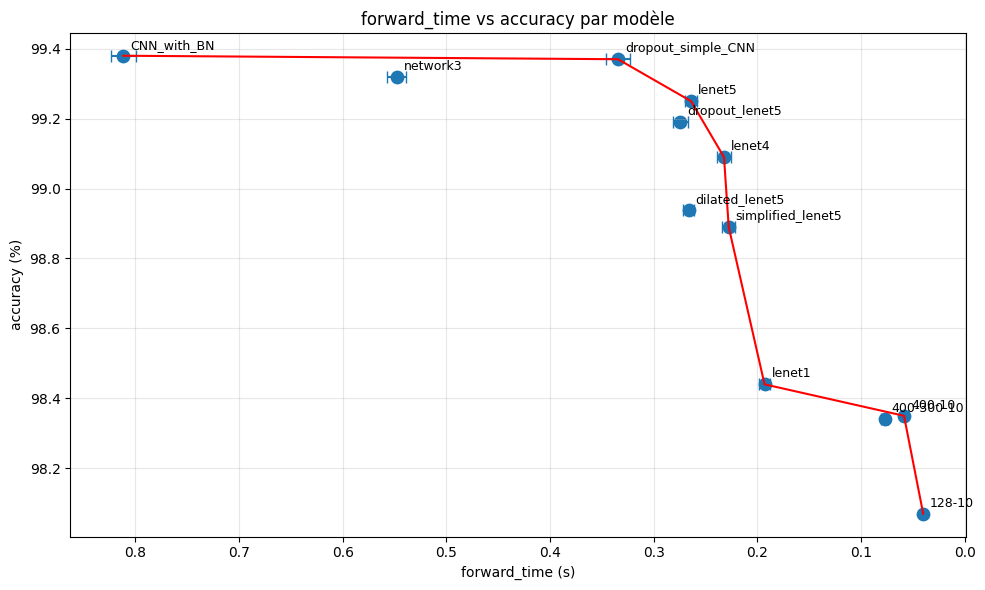

In [56]:
plot_time_vs_accuracy("forward_time")

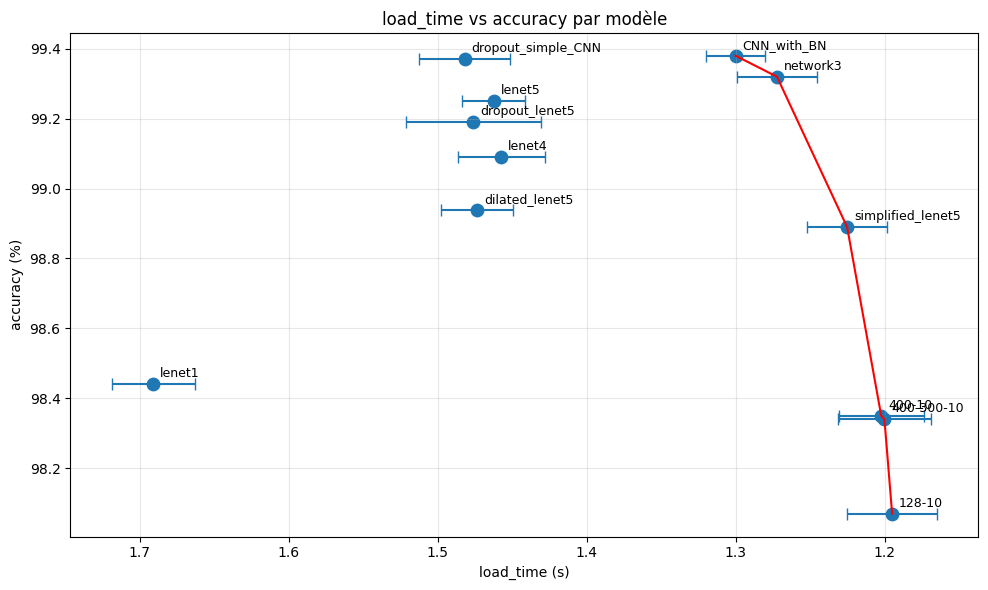

In [57]:
plot_time_vs_accuracy("load_time")

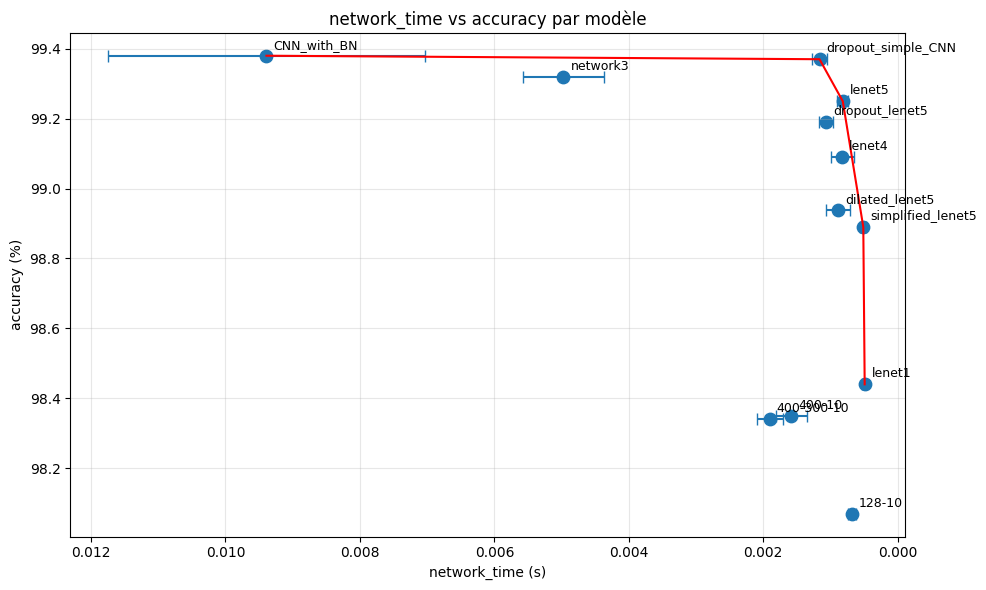

In [58]:
plot_time_vs_accuracy("network_time")

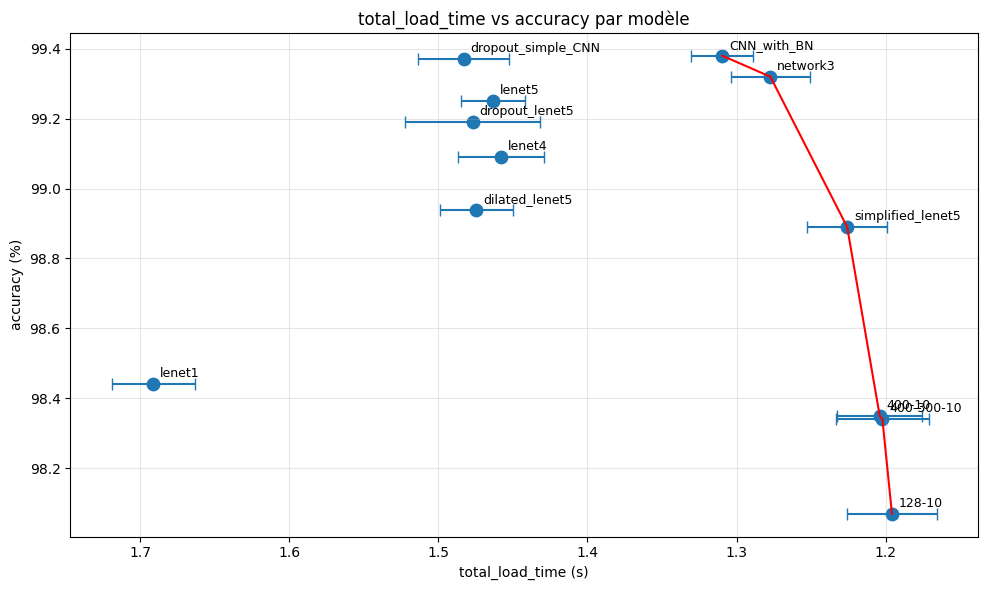

In [59]:
plot_time_vs_accuracy("total_load_time")

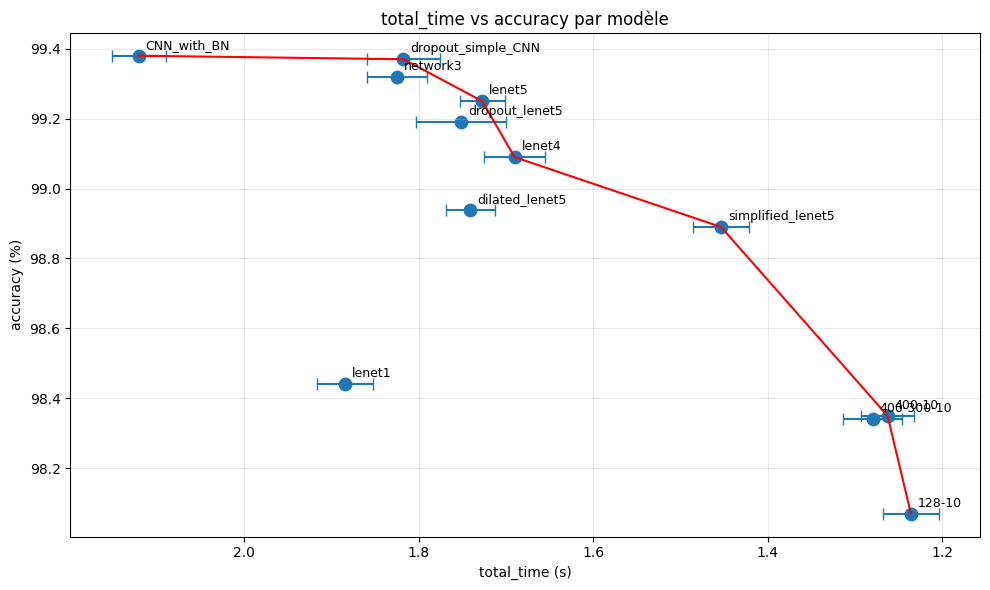

In [60]:
plot_time_vs_accuracy("total_time")

Classement des réseaux par temps

In [ ]:
network_time_sorted = df_means.sort_values('network_time', ascending=True).index.tolist()
forward_time_sorted = df_means.sort_values('forward_time', ascending=True).index.tolist()
load_time_sorted = df_means.sort_values('load_time', ascending=True).index.tolist()

ranking_df = pd.DataFrame({
    'Rang': range(1, 13),
    'Network Time': network_time_sorted,
    'Forward Time': forward_time_sorted,
    'Load Time': load_time_sorted
})

def style_dataframe(df):
    
    unique_names = set(df['Network Time'].tolist() + df['Forward Time'].tolist() + df['Load Time'].tolist())
    colors = plt.cm.tab20(np.linspace(0, 1, len(unique_names)))
    color_map = {name: mcolors.to_hex(color) for name, color in zip(sorted(unique_names), colors)}
    
    # Fonction pour appliquer les couleurs
    def apply_colors(val):
        if val == 'Rang':
            return 'background-color: #f0f0f0'
        if pd.isna(val):
            return ''
        hex_color = color_map.get(val, '#ffffff')
        return f'background-color: {hex_color}; color: black; font-weight: bold'
    
    styled = df.style.map(apply_colors)
    styled.set_properties(**{'text-align': 'center', 'padding': '8px'})
    
    return styled

style_dataframe(ranking_df)

,Rang,Network Time,Forward Time,Load Time
0,1,lenet1,128-10,128-10
1,2,simplified_lenet5,400-10,400-300-10
2,3,128-10,400-300-10,400-10
3,4,lenet5,lenet1,simplified_lenet5
4,5,lenet4,simplified_lenet5,network3
5,6,dilated_lenet5,lenet4,CNN_with_BN
6,7,dropout_lenet5,lenet5,lenet4
7,8,dropout_simple_CNN,dilated_lenet5,lenet5
8,9,400-10,dropout_lenet5,dilated_lenet5
9,10,400-300-10,dropout_simple_CNN,dropout_lenet5


Etude de robustesse

In [2]:
df2 = pd.read_json("created_files/accuracies_rotation_robustesse.json")

In [3]:
df2 = df2.T

In [4]:
df2

,0,5,10,15,20,25,30,35
network3,99.32,99.20,98.99,98.64,98.16,97.26,95.85,93.87
CNN_with_BN,99.38,99.37,98.98,98.72,98.08,96.82,94.90,92.99
dropout_simple_CNN,99.37,99.27,99.03,98.71,98.22,97.28,95.96,93.71
dropout_lenet5,99.19,99.13,99.08,98.67,98.10,97.19,95.57,93.43
lenet5,99.25,99.15,98.86,98.54,98.00,96.97,95.41,92.94
lenet4,99.09,98.93,98.72,98.32,97.72,96.73,95.26,93.35
simplified_lenet5,98.89,98.81,98.55,98.06,97.32,96.36,95.08,92.73
dilated_lenet5,98.94,98.83,98.54,98.04,97.30,95.99,93.69,90.95
lenet1,98.44,98.20,97.95,97.39,96.58,95.11,93.01,90.07
400-300-10,98.34,98.31,97.82,97.06,95.94,94.13,91.64,87.77


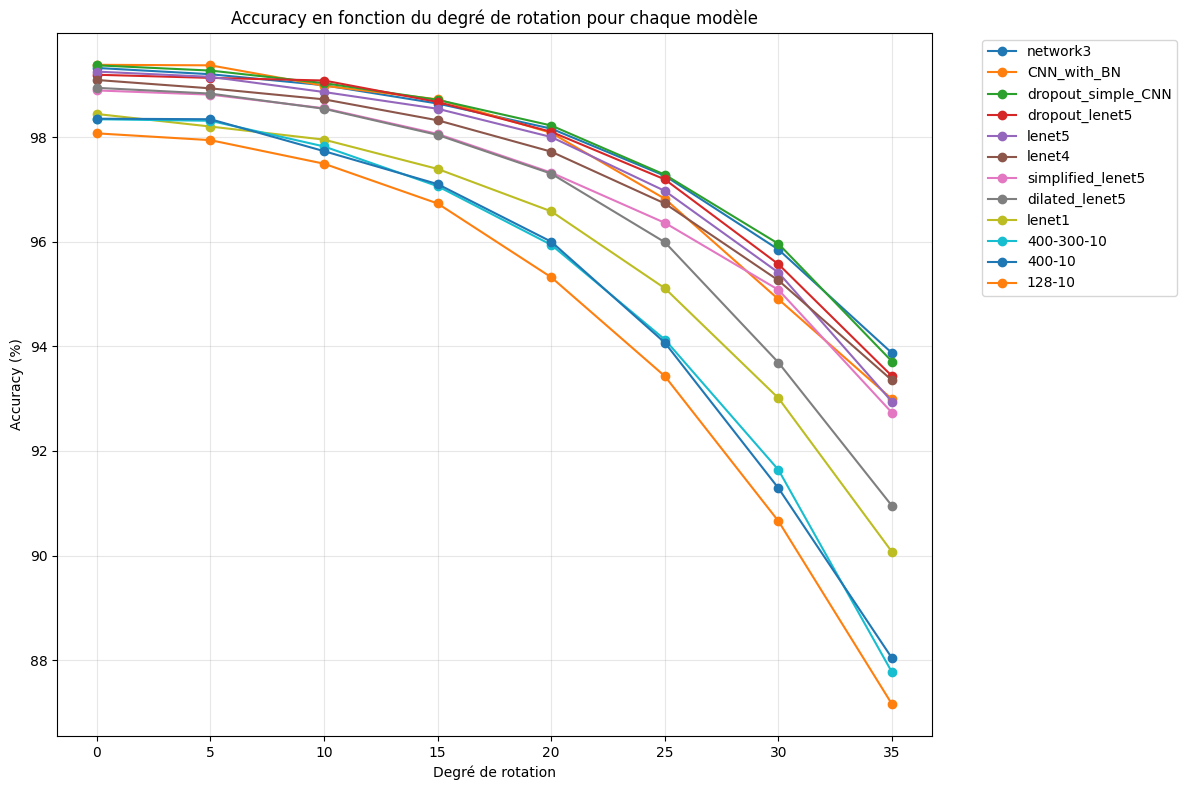

In [ ]:
plt.figure(figsize=(12, 8))
angles = df2.columns.astype(float)
for model in df2.index:
    plt.plot(angles, df2.loc[model].values, marker='o', label=model)

plt.xlabel('Degré de rotation')
plt.ylabel('Accuracy (%)')
plt.title('Accuracy en fonction du degré de rotation pour chaque modèle')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Les réseaux les plus pertinents semblent être :

network3,

dropout_simple_CNN,

dropout_lenet5,

lenet4,

CNN_with_BN,

lenet5,

simplified_lenet5.

In [11]:
df3 = pd.read_json("created_files/accuracies_translation_robustesse.json", convert_axes=False)

In [12]:
df3 = df3.T

In [13]:
df3

,0.0,0.02,0.04,0.06,0.08,0.1,0.12,0.14
network3,99.32,99.24,98.77,97.79,95.98,91.94,86.74,79.07
CNN_with_BN,99.38,99.26,98.86,98.07,96.35,92.10,86.92,79.16
dropout_simple_CNN,99.37,99.32,98.59,97.51,94.88,89.96,84.23,75.72
dropout_lenet5,99.19,99.11,98.78,98.10,96.45,92.92,88.22,80.75
lenet5,99.25,99.18,98.53,97.43,94.96,90.64,85.16,76.88
lenet4,99.09,98.91,98.35,97.31,94.93,90.56,84.94,76.16
simplified_lenet5,98.89,98.77,98.19,97.04,94.65,89.88,84.41,76.10
dilated_lenet5,98.94,98.71,97.89,96.82,94.27,89.47,84.27,76.20
lenet1,98.44,98.41,97.85,96.78,94.40,90.34,85.89,78.99
400-300-10,98.34,97.97,96.39,93.00,86.65,78.13,69.24,58.90


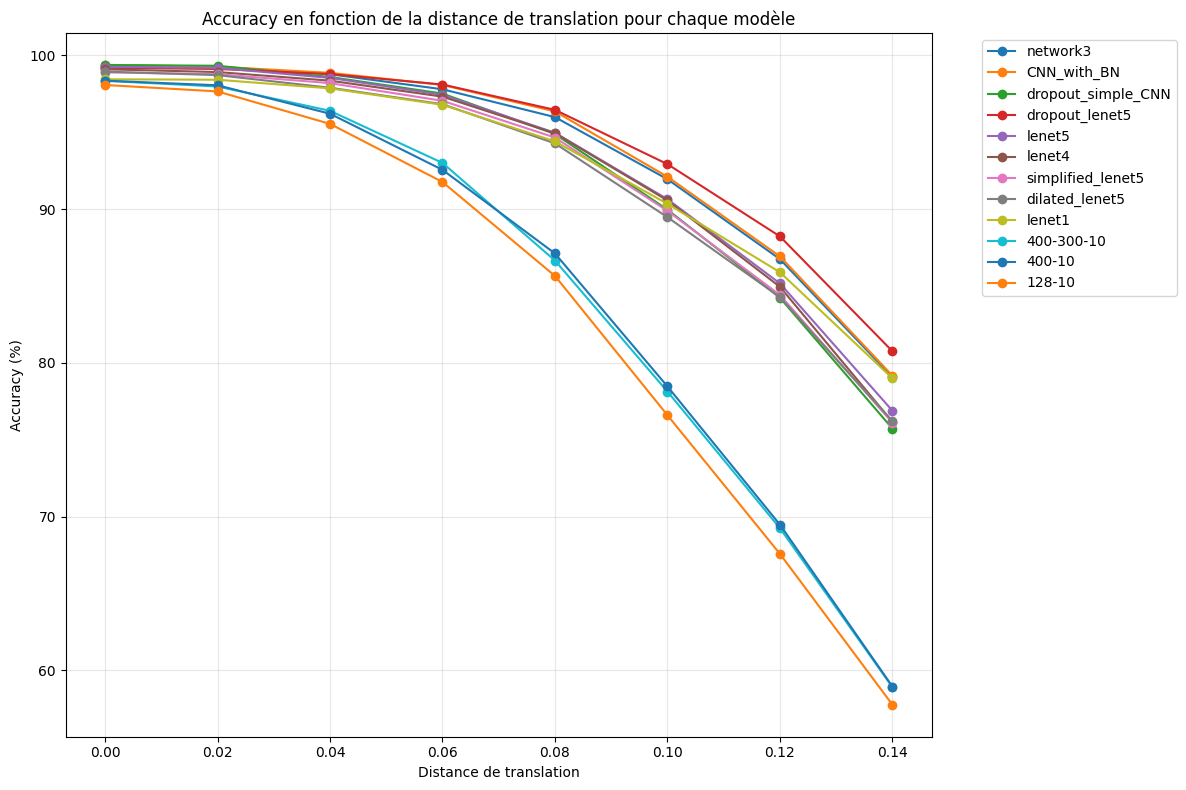

In [14]:
plt.figure(figsize=(12, 8))
angles = df3.columns.astype(float)
for model in df3.index:
    plt.plot(angles, df3.loc[model].values, marker='o', label=model)

plt.xlabel('Distance de translation')
plt.ylabel('Accuracy (%)')
plt.title('Accuracy en fonction de la distance de translation pour chaque modèle')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Les réseaux les plus pertinents semblent être :

dropout_lenet5,

CNN_with_BN,

network3,

lenet1,

lenet5,

lenet4,

dilated_lenet5,

simplified_lenet5,

dropout_simple_CNN.

In [16]:
df4 = pd.read_json("created_files/accuracies_affine_robustesse.json", convert_axes=False)

In [17]:
df4 = df4.T

In [18]:
df4

,"(0.0, 0)","(0.03, 5)","(0.06, 10)","(0.09, 15)","(0.12, 20)","(0.15, 25)","(0.18, 30)","(0.21, 35)"
network3,99.32,98.79,97.26,93.78,83.29,69.72,55.79,44.73
CNN_with_BN,99.38,98.86,97.23,93.08,82.16,68.70,55.11,44.14
dropout_simple_CNN,99.37,98.72,97.15,92.31,80.83,66.67,53.04,41.67
dropout_lenet5,99.19,98.84,97.59,94.23,85.11,71.95,59.36,47.56
lenet5,99.25,98.59,96.81,92.32,81.36,67.56,54.24,43.58
lenet4,99.09,98.39,96.65,92.27,80.82,67.04,54.24,43.12
simplified_lenet5,98.89,98.31,96.12,91.78,80.49,66.74,53.63,42.68
dilated_lenet5,98.94,98.16,96.08,91.14,79.97,65.90,53.13,42.73
lenet1,98.44,98.02,95.78,91.64,81.69,70.06,57.74,46.74
400-300-10,98.34,96.61,91.45,81.38,64.30,48.45,37.18,28.76


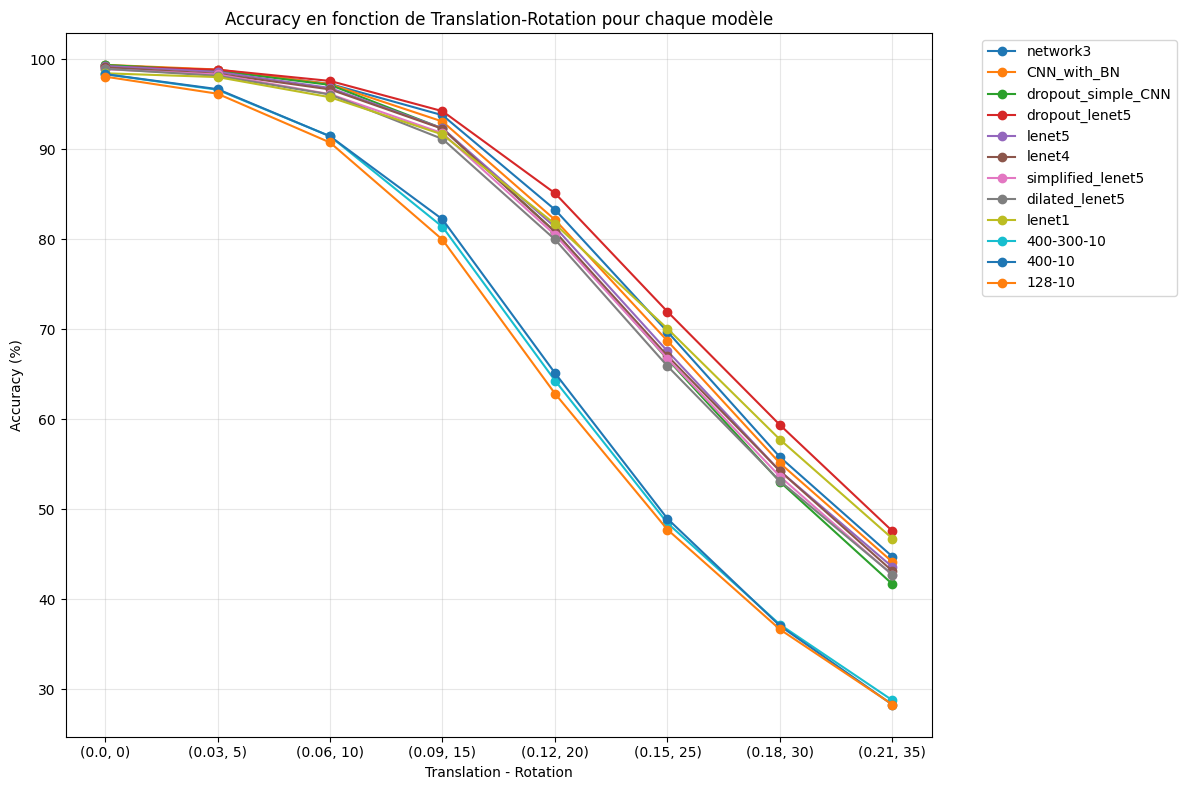

In [22]:
plt.figure(figsize=(12, 8))
tuples = df4.columns
for model in df4.index:
    plt.plot(tuples, df4.loc[model].values, marker='o', label=model)

plt.xlabel('Translation - Rotation')
plt.ylabel('Accuracy (%)')
plt.title('Accuracy en fonction de Translation-Rotation pour chaque modèle')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [8]:
cm = pd.read_json("created_files/cm")

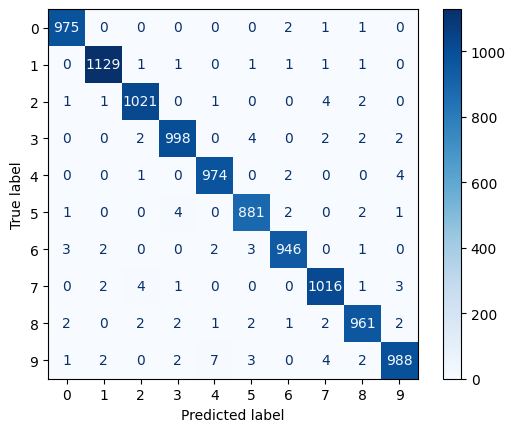

In [9]:
disp = ConfusionMatrixDisplay(confusion_matrix=cm.values, display_labels=cm.columns)
disp.plot(cmap=plt.cm.Blues, values_format='.0f')
plt.show()

In [10]:
cm_affine = pd.read_json("created_files/cm_affine")

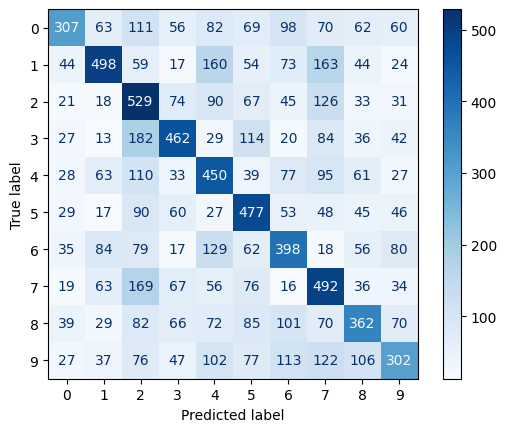

In [12]:
disp = ConfusionMatrixDisplay(confusion_matrix=cm_affine.values, display_labels=cm_affine.columns)
disp.plot(cmap=plt.cm.Blues, values_format='.0f')
plt.show()

In [4]:
pd.read_json("created_files/"+ net_name +".json")
df["confusion_matrix"]

KeyError: 'confusion_matrix'

In [3]:
for net_name in net_names:
    print("net name : "+net_name)
    df = pd.read_json("created_files/"+ net_name +".json")
    matrix = np.array(df.at[0, "confusion_matrix"])
    disp = ConfusionMatrixDisplay(confusion_matrix=matrix.values, display_labels=matrix.columns)
    disp.plot(cmap=plt.cm.Blues, values_format='.0f')
    plt.show()

net name : network3


KeyError: 'confusion_matrix'